# Exemplo 4 — PVI de Segunda Ordem

**Slide p. 36** — Resolver

$$y'' = 2y' - 3y + \cos x, \quad y(0)=3, \quad y'(0)=8$$

com RK4, $x \in [0, 3]$ e $h = 0{,}1$.

**Substituição:** $w = y'$, gerando o sistema
$y' = w$ e $w' = 2w - 3y + \cos x$.

    x             y            y'
  0.0      3.000000      8.000000
  0.5      7.711975     10.001509
  1.0     11.532670      3.151465
  1.5      8.174985    -19.609950
  2.0    -10.810814    -58.118622
  2.5    -49.472056    -92.755524
  3.0    -94.938564    -74.791307


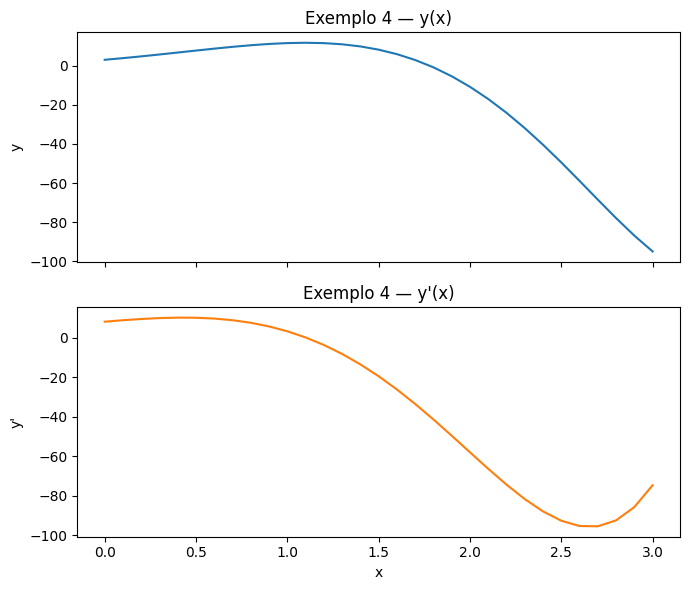

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Sistema: u = [y, w=y']
def fy(x, y, w):
    return w

def fw(x, y, w):
    return 2*w - 3*y + np.cos(x)

x0, y0, w0, h = 0.0, 3.0, 8.0, 0.1
x_end = 3.0

x, y, w = x0, y0, w0
xs, ys, ws = [x], [y], [w]

while x < x_end - 1e-10:
    k1_y = fy(x,       y,             w)
    k1_w = fw(x,       y,             w)

    k2_y = fy(x + h/2, y + k1_y*h/2, w + k1_w*h/2)
    k2_w = fw(x + h/2, y + k1_y*h/2, w + k1_w*h/2)

    k3_y = fy(x + h/2, y + k2_y*h/2, w + k2_w*h/2)
    k3_w = fw(x + h/2, y + k2_y*h/2, w + k2_w*h/2)

    k4_y = fy(x + h,   y + k3_y*h,   w + k3_w*h)
    k4_w = fw(x + h,   y + k3_y*h,   w + k3_w*h)

    y = y + (k1_y + 2*k2_y + 2*k3_y + k4_y) * h / 6
    w = w + (k1_w + 2*k2_w + 2*k3_w + k4_w) * h / 6
    x = x + h

    xs.append(x); ys.append(y); ws.append(w)

print(f"{'x':>5}  {'y':>12}  {'y\'':>12}")
for xi, yi, wi in zip(xs[::5], ys[::5], ws[::5]):
    print(f"{xi:>5.1f}  {yi:>12.6f}  {wi:>12.6f}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6), sharex=True)
ax1.plot(xs, ys); ax1.set_ylabel("y"); ax1.set_title("Exemplo 4 — y(x)")
ax2.plot(xs, ws, color='tab:orange'); ax2.set_ylabel("y'"); ax2.set_xlabel("x")
ax2.set_title("Exemplo 4 — y'(x)")
plt.tight_layout(); plt.show()
